In [1]:
#!/usr/bin/python3
import sys
import os

sys.path.append(os.path.abspath(".."))

import pickle
import Scripts.utils
from Scripts.utils import *
import numpy as np
from numpy import array
import glob
import pandas as pd
import matplotlib.pyplot as plt
import random, math
import matplotlib.ticker as ticker
import seaborn as sns
from rich.console import Console
from rich.table import Table
from matplotlib.colors import ListedColormap
from sklearn.model_selection import KFold
from tensorflow.keras.utils import plot_model
import visualkeras
from PIL import ImageFont, Image
from sklearn.metrics import r2_score

import copy
import random, math
import time
from joblib import dump
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from sklearn.metrics import mean_squared_error as mse
from tensorflow.keras.metrics import RootMeanSquaredError as rmse

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

np.seterr(divide='ignore', invalid='ignore')

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

dataSamplesGev = np.load('../Data/lzt_dictClus7x7_99k_SignalsSamples_e50_GeV.pkl', allow_pickle=True)
dataAmplitudeGev = np.load('../Data/lzt_dictClus7x7_99k_Amplitudes_e50_GeV.pkl', allow_pickle=True)

# Leitura de elementos do sinal do vetor de amostras
EtruthSampGeV = dataSamplesGev['E'] 
XTcSampGeV = dataSamplesGev['XT_C']
XTlSampGeV = dataSamplesGev['XT_L']
XTrSampGeV = dataSamplesGev['XT_R']
NoiseSampGeV = dataSamplesGev['Noise']

# Sinal de leitura de energia somado as contribuições de Crosstalk e ruído
xDataSamplesGeV = np.add(np.add(np.add(np.add(EtruthSampGeV, XTcSampGeV), XTlSampGeV), NoiseSampGeV), XTrSampGeV)

# Leitura de elementos do sinal do vetor de amplitudes
EtruthAmpGeV = dataAmplitudeGev['E']
XTcAmpGeV = dataAmplitudeGev['XT_C']
XTlAmpGeV = dataAmplitudeGev['XT_L']
XTrAmpGeV = dataAmplitudeGev['XT_R']
NoiseAmpGeV = dataAmplitudeGev['Noise']

# Sinal de leitura de energia somado as contribuições de Crosstalk e ruído
xDataAmpGeV = np.add(np.add(np.add(np.add(EtruthAmpGeV, XTcAmpGeV), XTlAmpGeV), NoiseAmpGeV), XTrAmpGeV)

AmpTimeGeV  = OptFilt(EtruthSampGeV)
AmpTimeXTGeV  = OptFilt(xDataSamplesGeV)

AmplitudesGeVOptFilt = AmpTimeGeV['Clusters']['Amplitude']
XTAmplitudesGeVOptFilt = AmpTimeXTGeV['Clusters']['Amplitude']

shape_val = xDataSamplesGeV.shape[0]

TimesGeVOptFilt = AmpTimeGeV['Clusters']['Time']

scaler_data_amp = MinMaxScaler()
scaler_etruth = MinMaxScaler()
scaler_time = MinMaxScaler()
scaler_samp = MinMaxScaler()
scaler_data_samp = MinMaxScaler()
xDataAmpGeV_Normalized = scaler_data_amp.fit_transform(xDataAmpGeV)
EtruthAmpGeV_Normalized = scaler_etruth.fit_transform(EtruthAmpGeV)
TimesGeVOptFilt_Normalized = scaler_time.fit_transform(TimesGeVOptFilt)

toGeV = 1000
xDataSampGeV_Normalized = scaler_data_samp.fit_transform(xDataSamplesGeV)
EtruthSampGeV_Normalized = scaler_samp.fit_transform(EtruthSampGeV)

toGeV = 1000

ij_cell = ['-3,3' , '-2,3' , '-1,3' , '0,3' , '1,3' , '2,3' , '3,3' , 
           '-3,2' , '-2,2' , '-1,2' , '0,2' , '1,2' , '2,2' , '3,2' , 
           '-3,1' , '-2,1' , '-1,1' , '0,1' , '1,1' , '2,1' , '3,1' , 
           '-3,0' , '-2,0' , '-1,0' , '0,0' , '1,0' , '2,0' , '3,0' , 
           '-3,-1', '-2,-1', '-1,-1', '0,-1', '1,-1', '2,-1', '3,-1', 
           '-3,-2', '-2,-2', '-1,-2', '0,-2', '1,-2', '2,-2', '3,-2', 
           '-3,-3', '-2,-3', '-1,-3', '0,-3', '1,-3', '2,-3', '3,-3' ]

Scaled_EtruthSampGeV = EtruthSampGeV.astype('float32')/toGeV
Scaled_xDataSampGeV_Normalized = xDataSampGeV_Normalized.astype('float32')/toGeV

E_truth_energy_toConv = Scaled_EtruthSampGeV.reshape(shape_val * 4, 7, 7, 1)
XTData_denoise_toConv = xDataSampGeV_Normalized.reshape(shape_val * 4, 7, 7, 1)

2026-05-12 19:38:02.997815: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-12 19:38:03.007661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778625483.018807  141383 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778625483.022238  141383 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 19:38:03.034997: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Num GPUs Available:  1


In [2]:
from sklearn.model_selection import train_test_split

X = XTData_denoise_toConv           
y = E_truth_energy_toConv  

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42
)

In [3]:
def scale_X(X, scaler):
    Xn = scaler.transform(X.reshape(len(X), -1))
    return Xn.reshape(len(X), 7, 7, 1)

def scale_y(y, scaler):
    yn = scaler.transform(y.reshape(len(y), -1))
    return yn.reshape(len(y), 7, 7, 1)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_x.fit(X_train.reshape(len(X_train), -1))
scaler_y.fit(y_train.reshape(len(y_train), -1))

MinMaxScaler()

In [ ]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()


scaler_x.fit(X_train.reshape(len(X_train), -1))
scaler_y.fit(y_train.reshape(len(y_train), -1))


study = ConvDenoisingAutoencoderV2.optimize_with_optuna(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    scaler_x=scaler_x,
    scaler_y=scaler_y,
    n_trials=40,
    max_epochs=30
)

In [4]:
conv_Denoise = ConvDenoisingAutoencoderV2(input_shape=(7, 7, 1), 
                                        filters=(76, 108),
                                        kernel_size=(4, 4),
                                        activation_func = 'relu',
                                        padding_mode = 'same',
                                        max_polling = 3,
                                        up_sampling = 3,
                                        optimizing_func=tf.keras.optimizers.Adam(learning_rate=0.0003548496634044595),
                                        loss_func = 'mse',
                                        epochs_ = 30,
                                        batch_size_ = 64,
                                        validation_split_ = 0.1
                                        )
Denoise_Network = conv_Denoise.train(X_train, y_train, X_val, y_val)

I0000 00:00:1778625788.631911  141383 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4083 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 76)       │         1,292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 7, 76)       │           304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 7, 7, 76)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 76)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 108)      │       131,436 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 3, 108)      │           432 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3, 3, 108)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 3, 3, 108)      │       186,732 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3, 3, 108)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 9, 9, 108)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 9, 9, 1)        │         1,729 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 1)        │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 7, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 1)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,929 (1.23 MB)

 Trainable params: 321,559 (1.23 MB)

 Non-trainable params: 370 (1.45 KB)

I0000 00:00:1778625791.306890  167435 service.cc:148] XLA service 0x7bff30009220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778625791.306960  167435 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-05-12 19:43:11.388945: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778625791.571655  167435 cuda_dnn.cc:529] Loaded cuDNN version 91400
I0000 00:00:1778625793.382595  167435 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - loss: 0.2049 - val_loss: 0.0056
Epoch 2/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0052 - val_loss: 0.0044
Epoch 3/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 4/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0021 - val_loss: 0.0015
Epoch 5/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 6/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 7/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 8/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 9/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 10/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 11/30
4030/4030 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/30
4030/40

In [ ]:
sample = E_truth_energy_toConv[0]

scaled = scaler_y.transform(
    sample.reshape(1, -1)
)

recovered = scaler_y.inverse_transform(scaled)

print(sample.reshape(-1)[:10])
print(recovered.reshape(-1)[:10])

In [5]:
y_true_real = scaler_y.inverse_transform(
    E_truth_energy_toConv.reshape(len(E_truth_energy_toConv), -1)
)

y_pred_real = scaler_x.inverse_transform(
    Denoise_Network.model.predict(XTData_denoise_toConv).reshape(len(E_truth_energy_toConv), -1)
)

E_truth_energy_toConv_resize = E_truth_energy_toConv.reshape(397968,49)

r2_real = r2_score(E_truth_energy_toConv_resize, y_pred_real)

12437/12437 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step


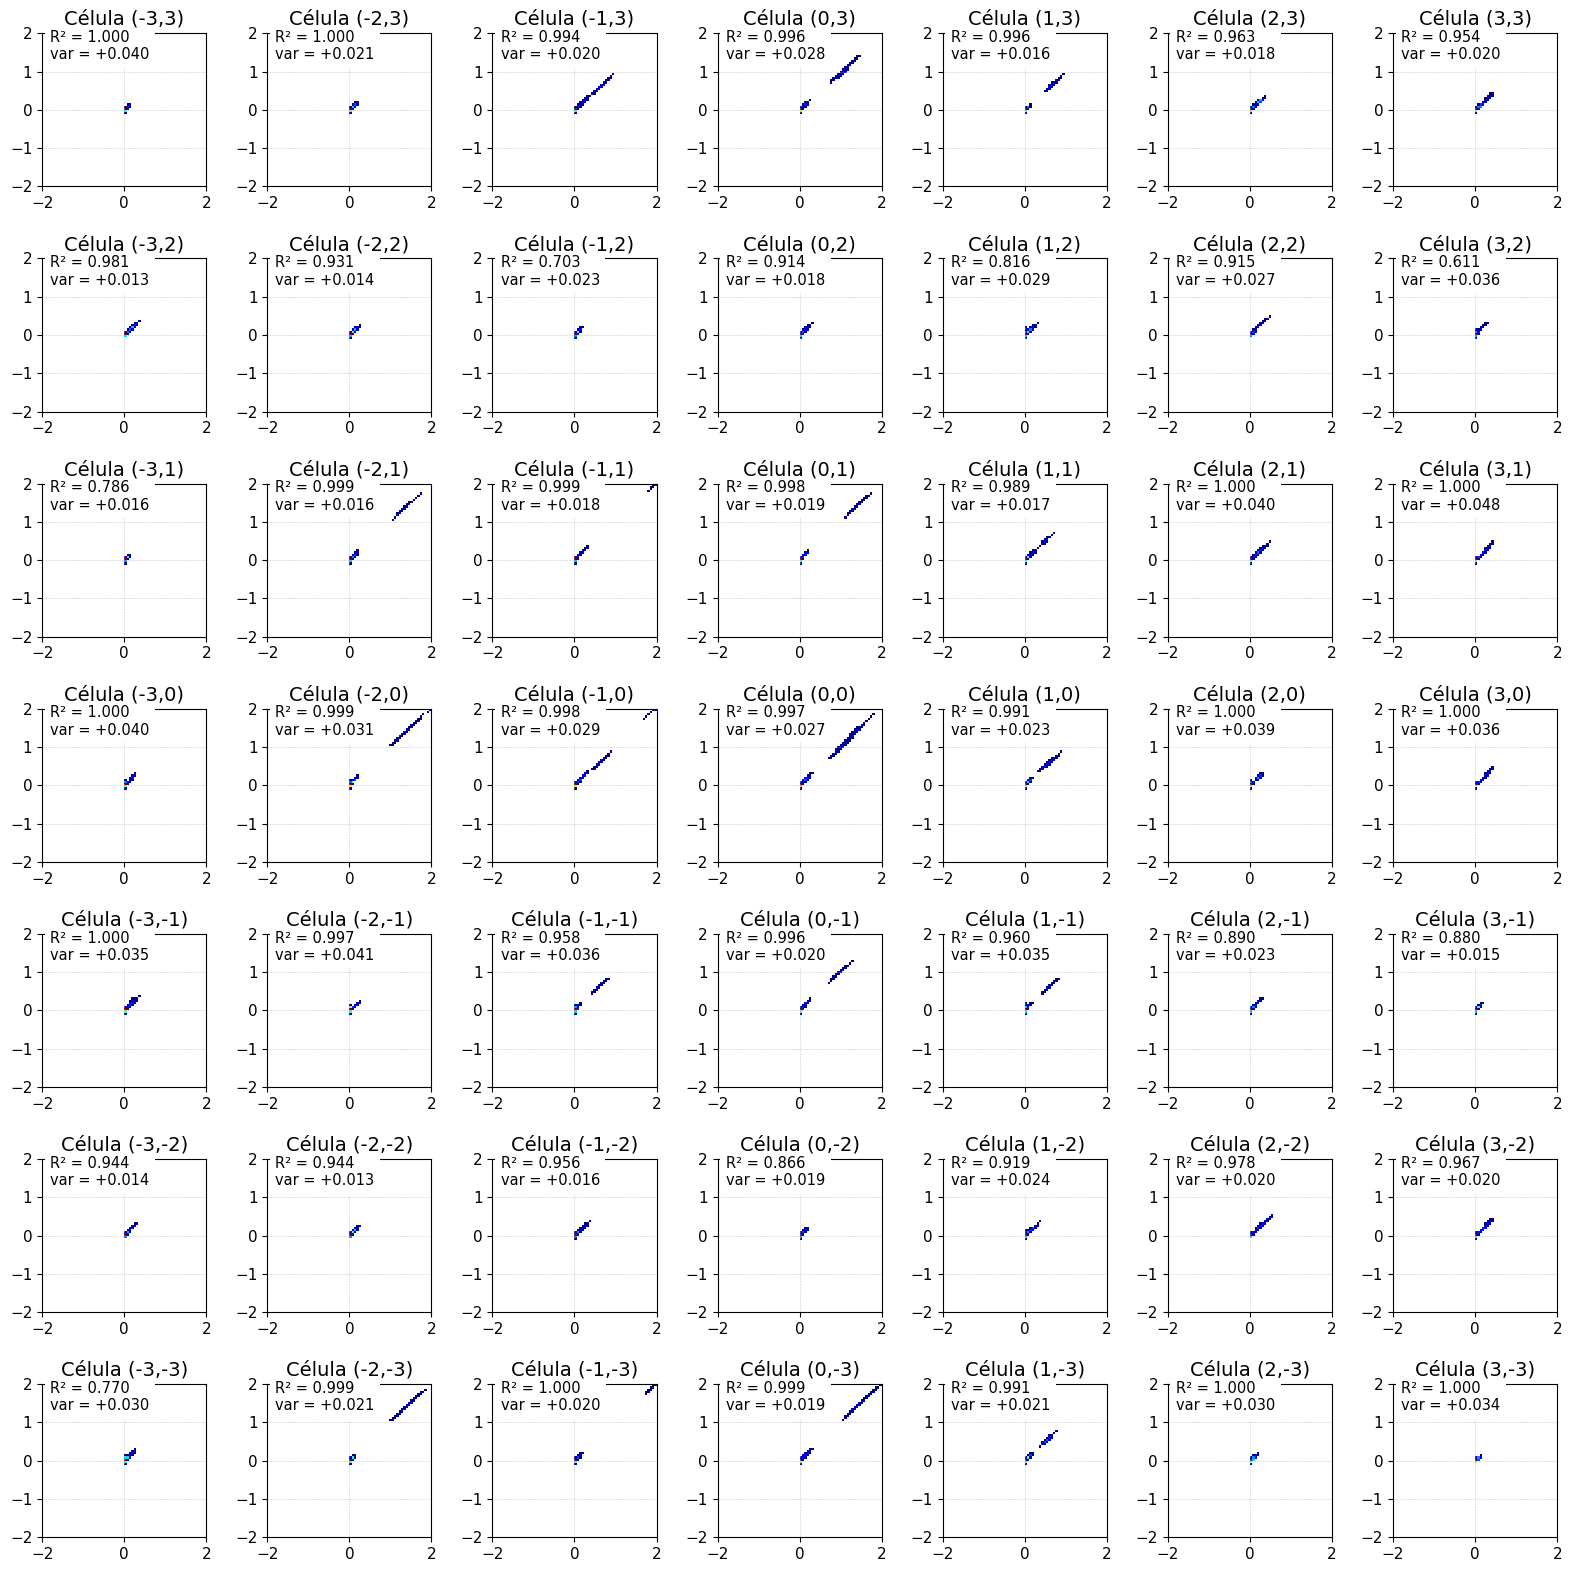

In [11]:
heatmap_all_cellsV2(E_truth_energy_toConv_resize, y_pred_real, bins=70, xlim=(-2,2), ylim=(-2,2)) 

In [21]:
y_pred_real.shape

(397968, 49)

In [28]:
print(E_truth_energy_toConv_resize.min(), E_truth_energy_toConv_resize.max())
print(y_pred_real.min(), y_pred_real.max())

-0.20203634 20.428759
0.0 20.374985


In [29]:
rmse_cells = []

for i in range(E_truth_energy_toConv_resize.shape[1]):
    rmse_i = np.sqrt(
        mean_squared_error(
            E_truth_energy_toConv_resize[:, i],
            y_pred_real[:, i]
        )
    )
    rmse_cells.append(rmse_i)

rmse_cells = np.array(rmse_cells)
rmse_map = rmse_cells.reshape(7, 7)

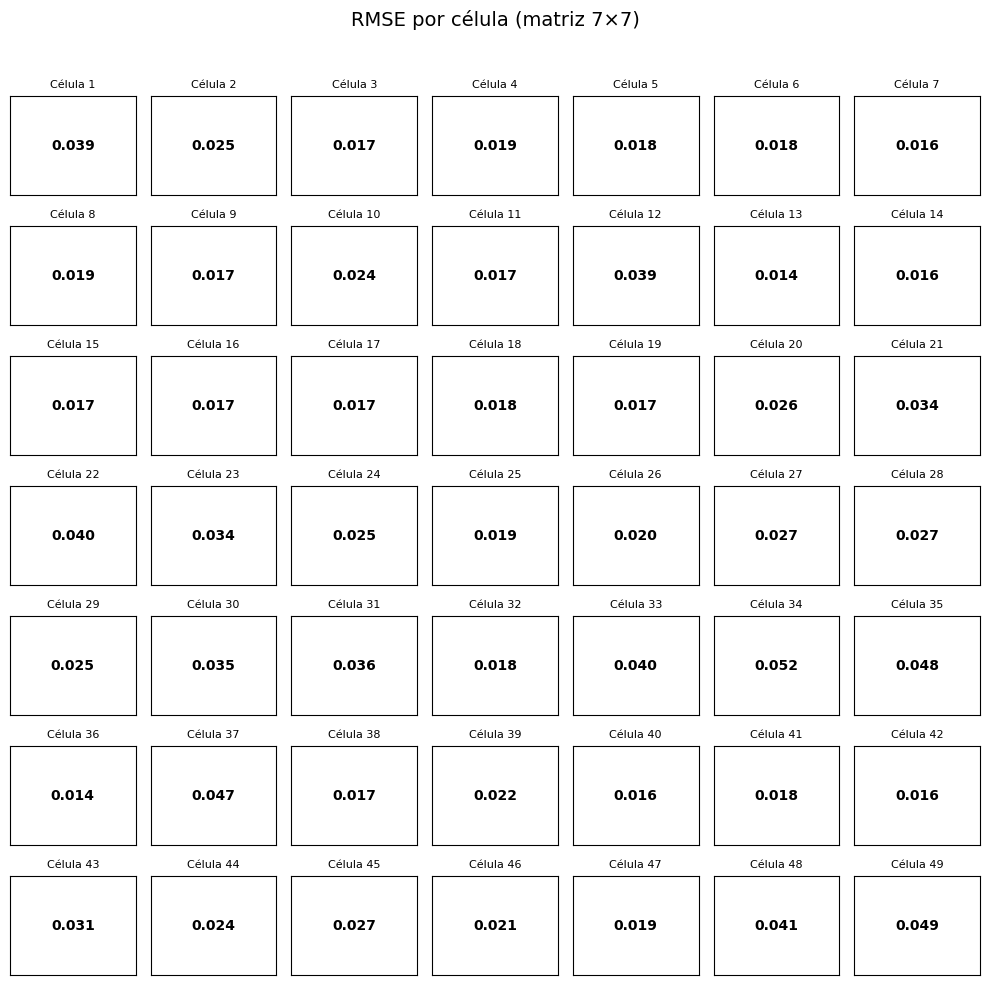

In [30]:
rmse_cells = np.array(rmse_cells)  # (49,)

fig, axes = plt.subplots(7, 7, figsize=(10, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.set_facecolor("white")

    # escreve o RMSE no centro da célula
    ax.text(
        0.5, 0.5,
        f"{rmse_cells[i]:.3f}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    ax.set_title(f"Célula {i+1}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(True)

plt.suptitle("RMSE por célula (matriz 7×7)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [35]:
E_truth_to_filt = E_truth_energy_toConv_resize.reshape(99492, 196)
y_pred_to_filt = y_pred_real.reshape(99492, 196)

In [36]:
filtered = OptFilt(y_pred_to_filt)

In [37]:
predicted_energy = filtered['Clusters']['Amplitude']

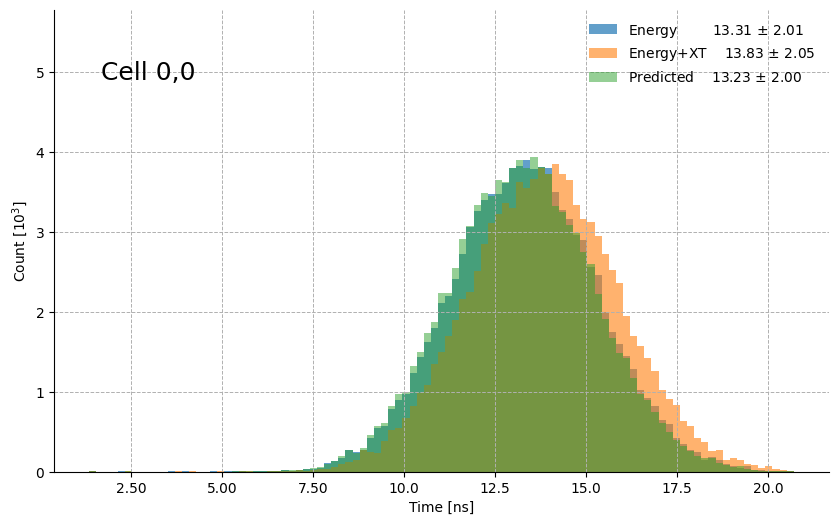

In [43]:
## plotting for hotest cell according to cell addressing
cell = 24

unit = 'GeV'
if unit.lower() == 'gev': toGeV = 1
else: toGeV = 1

#plotHisto(map_EtruthAmp_cells_cropped[:, cell]/toGeV, xDataAmp10GeV_error[:, cell]/toGeV, label='energy', legend=['E', 'E+XT'], unit=unit, text=f'Cell {ij_cell[cell]}')
plotHisto(AmplitudesGeVOptFilt[:, cell]/1000, XTAmplitudesGeVOptFilt[:, cell]/1000, predicted_energy[:, cell], label='time', legend=['Energy', 'Energy+XT', 'Predicted'], unit=unit, text=f'Cell {ij_cell[cell]}')

In [1]:
import os

## cria a pasta onde os histogramas serão salvos
save_dir = "histogramas_cells_energy"
os.makedirs(save_dir, exist_ok=True)

unit = 'GeV'

if unit.lower() == 'gev':
    toGeV = 1
else:
    toGeV = 1

## loop para todas as 49 células
for cell in range(49):

    ## nome do arquivo
    filename = os.path.join(
        save_dir,
        f"hist_cell_{cell}_{ij_cell[cell]}.png"
    )

    ## cria a figura
    fig = plt.figure(figsize=(8,6))

    ## plota o histograma
    plotHisto(
        AmplitudesGeVOptFilt[:, cell] / 1000,
        XTAmplitudesGeVOptFilt[:, cell] / 1000,
        predicted_energy[:, cell],
        label='time',
        legend=['Energy', 'Energy+XT', 'Predicted'],
        unit=unit,
        text=f'Cell {ij_cell[cell]}'
    )

    ## salva a figura
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    ## fecha a figura para evitar consumo excessivo de memória
    plt.close(fig)

print(f"Histogramas salvos em: {save_dir}")

NameError: name 'ij_cell' is not defined

In [44]:
import pickle

with open("AmplitudesGeVOptFilt.pkl", "wb") as f:
    pickle.dump(AmplitudesGeVOptFilt, f)

with open("XTAmplitudesGeVOptFilt.pkl", "wb") as f:
    pickle.dump(XTAmplitudesGeVOptFilt, f)

with open("predicted_energy.pkl", "wb") as f:
    pickle.dump(predicted_energy, f)   

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(Denoise_Network.history['loss'], label = "Training Loss",linewidth=4)
plt.plot(Denoise_Network.history['val_loss'], label = "Validation Loss",linewidth=4)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.show()

In [ ]:
study = ConvDenoisingAutoencoderV2.optimize_with_optuna(
    XTData_denoise_toConv, E_truth_energy_toConv,
    n_trials=30,
    max_epochs=20
)

In [ ]:
import joblib

joblib.dump(study, "dae_conv_samples.pkl")

In [ ]:
k_folds_ = 20
shuffle_= True
random_state_ = None
kf = KFold(n_splits=k_folds_, shuffle=shuffle_, random_state=random_state_)
train_losses = []
val_losses = []
all_history = []
fold_results= []
epochs = 30

In [ ]:
for train_index, val_index in kf.split(X_train):

    dae_build_cross_val = ConvDenoisingAutoencoderV2(filters=(76, 108),
    kernel_size=(4, 4),
    batch_size_=64,
    validation_split_=0.1,
    loss_func="mse",
    optimizing_func=tf.keras.optimizers.Adam(learning_rate=0.0003548496634044595),
    activation_func="relu",
    epochs_ = 30,
    up_sampling=3,
    max_polling=3,)
    # train_data, val_data = X_train[train_index], X_train[val_index]
    # train_target, val_target = y_train[train_index], y_train[val_index]
    history = dae_build_cross_val.train(X_train, y_train, X_val, y_val)

    fold_results.append(history)

# mean_loss = np.mean(val_losses)
# print(f"Perda média entre todos os folds: {mean_loss}")

In [ ]:
train_curves = []
val_curves = []

for history_obj in fold_results:
    train_curves.append(history_obj.history["loss"])
    if "val_loss" in history_obj.history:
        val_curves.append(history_obj.history["val_loss"])

min_epochs = min(len(c) for c in train_curves)

train_curves = np.array([c[:min_epochs] for c in train_curves])
val_curves   = np.array([c[:min_epochs] for c in val_curves])

mean_train = np.mean(train_curves, axis=0)
mean_val   = np.mean(val_curves, axis=0)

epochs = range(len(mean_train))

plt.figure(figsize=(12, 6))

plt.plot(epochs, mean_train, label="Average Train Loss")
plt.plot(epochs, mean_val, "--", label="Average Validation Loss")

plt.locator_params(axis='x', nbins=30)
plt.locator_params(axis='y', nbins=10)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
train_curves = []
val_curves = []

for history_obj in fold_results:
    train_curves.append(np.array(history_obj.history["loss"]))
    
    if "val_loss" in history_obj.history:
        val_curves.append(np.array(history_obj.history["val_loss"]))
    else:
        val_curves.append(None)  # mantém alinhamento entre folds

data = {
    "train_curves": train_curves,
    "val_curves": val_curves
}

with open("loss_curves_full_energy.pkl", "wb") as f:
    pickle.dump(data, f)

In [ ]:
for i in range(len(train_losses)):
    plt.figure(figsize=(12, 6))
    plt.plot(range(0, epochs+1), train_losses[i], label=f'Train Fold {i+1}')
    plt.plot(range(0, epochs+1), val_losses[i], '--', label=f'Validation Fold {i+1}')
    plt.title('Train and Validation Loss per Fold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig("10gev_fold: " + str(i), format="png")
    plt.show()

In [ ]:
conv_Denoise.autoencoder.save('dae_4x4_64x86_relu_adam_mse_10GeV_train2.h5')

In [ ]:
predicted_Conv2D = np.zeros((shape_val * 4, 7, 7, 1))
XTData_To_Filter = xDataSampGeV_Normalized.reshape((shape_val * 4, 7, 7, 1))
iterations = 4000 * 4
for index in range(iterations):
    print("Decoded the sample number " + str(index))
    predicted_Conv2D[index, :] = conv_Denoise.predict(XTData_To_Filter[index])

In [ ]:
crop_energy_true = EtruthSampGeV_Normalized[:iterations]*toGeV
crop_energy_pred = predicted_Conv2D[:iterations]*toGeV
crop_energy_pred = crop_energy_pred.reshape(4000, 196)
crop_energy_pred_opt_filt = OptFilt(crop_energy_pred)
energies_pred = crop_energy_pred_opt_filt['Clusters']['Amplitude']
AmpTimeGeV_crop = AmplitudesGeVOptFilt[:4000]


In [ ]:
AmpTimeGeV_crop

In [ ]:
R2 = scatter_cells_R2(energies_pred, AmpTimeGeV_crop)
print(R2.reshape(7,7))

In [ ]:
scatter_grid_density(energies_pred, AmpTimeGeV_crop)

In [ ]:

dados = {"energies_pred": energies_pred, "AmpTimeGeV_crop": AmpTimeGeV_crop, "info": "Energy Prediction"}

with open("energy_prediction.pkl", "wb") as f:
    pickle.dump(dados, f)